In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import zscore
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

import scanpy as sc 

In [2]:

# import importlib
# import SingleCellArchetype
# importlib.reload(SingleCellArchetype)
# importlib.reload(SingleCellArchetype.main)
# importlib.reload(SingleCellArchetype.utils)

from SingleCellArchetype.main import SCA
from SingleCellArchetype.utils import plot_archetype
from SingleCellArchetype.utils import get_relative_variation
from SingleCellArchetype.utils import shuffle_rows_per_col

# Load data

In [3]:
%%time
f_anndata_in  = "../../data/v1_multiome/superdupermegaRNA_hasraw_multiome_IT.h5ad"
adata = sc.read(f_anndata_in)

CPU times: user 1.75 s, sys: 14.9 s, total: 16.6 s
Wall time: 1min 33s


In [4]:
%%time
f_anndata_in  = "../../data/v1_multiome/run_sca/multiome_it_p21_hvg.h5ad"
adata_hvg = sc.read(f_anndata_in)
adata_hvg

CPU times: user 198 ms, sys: 874 ms, total: 1.07 s
Wall time: 4.84 s


AnnData object with n_obs × n_vars = 5399 × 4720
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'cond'
    var: 'feature_types'
    layers: 'lognorm', 'norm', 'zlognorm'

In [5]:
genes_hvg = adata_hvg.var.index.values

# Run SingleCellArchetype with different controls
- HVG (nHVGs) 
- PCA (ndim)
- number of archetypes (noc)
- level of pointedness (t-ratio)
- level of continuity (within type shuffling)
- enriched programs

In [6]:
from sklearn.decomposition import PCA

In [7]:
# types = [0]*len(adata_hvg)
types = adata_hvg.obs.Type.cat.codes
norm_mat = np.array(adata_hvg.layers['lognorm'])
sca = SCA(norm_mat, types)

In [8]:
x = norm_mat # [:,:300]
n_repeats = 20

nc, ng = x.shape
nc, ng, x.shape

(5399, 4720, (5399, 4720))

In [9]:
pca = PCA(n_components=10).fit(x)

shuffled_evs = []
for i in np.arange(n_repeats):
    x_gshuff = shuffle_rows_per_col(x)
    pca_gshuff = PCA(n_components=10).fit(x_gshuff)
    shuffled_evs.append(pca_gshuff.explained_variance_ratio_)

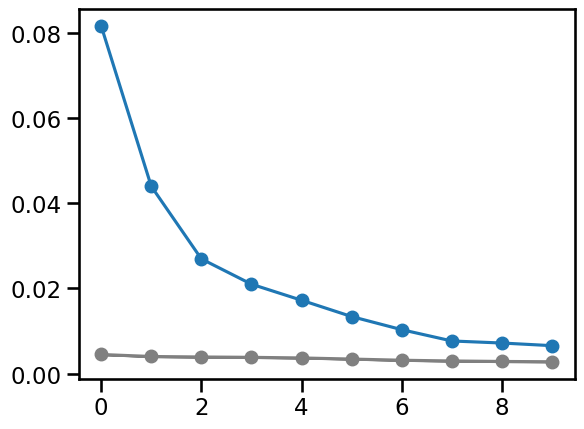

In [10]:
avg = np.mean(shuffled_evs, axis=0)
std = np.std(shuffled_evs, axis=0)

plt.plot(np.arange(10), pca.explained_variance_ratio_, '-o')
plt.plot(np.arange(10), avg, '-o', color='gray')
plt.fill_between(np.arange(10), 
                 avg-std, 
                 avg+std,
                 color='gray')

In [11]:
noc  = 3
ndim = noc-1
nrepeats = 3

In [12]:
# data 
sca.setup_feature_matrix(method='data')
xp, aa, _ = sca.proj_and_pcha(ndim, noc)
aa_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use data


In [13]:
# gshuff
sca.setup_feature_matrix(method='gshuff')
xp_gshuff, aa_gshuff, _ = sca.proj_and_pcha(ndim, noc)
aa_gshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use shuffled data


In [14]:
# tshuff 
sca.setup_feature_matrix(method='tshuff')
xp_tshuff, aa_tshuff, _ = sca.proj_and_pcha(ndim, noc)
aa_tshuff_boots = sca.bootstrap_proj_pcha(ndim, noc, nrepeats=nrepeats)

use per-type shuffled data


## plot

In [15]:
types_colorvec = np.char.add('C', sca.types_idx.astype(str))

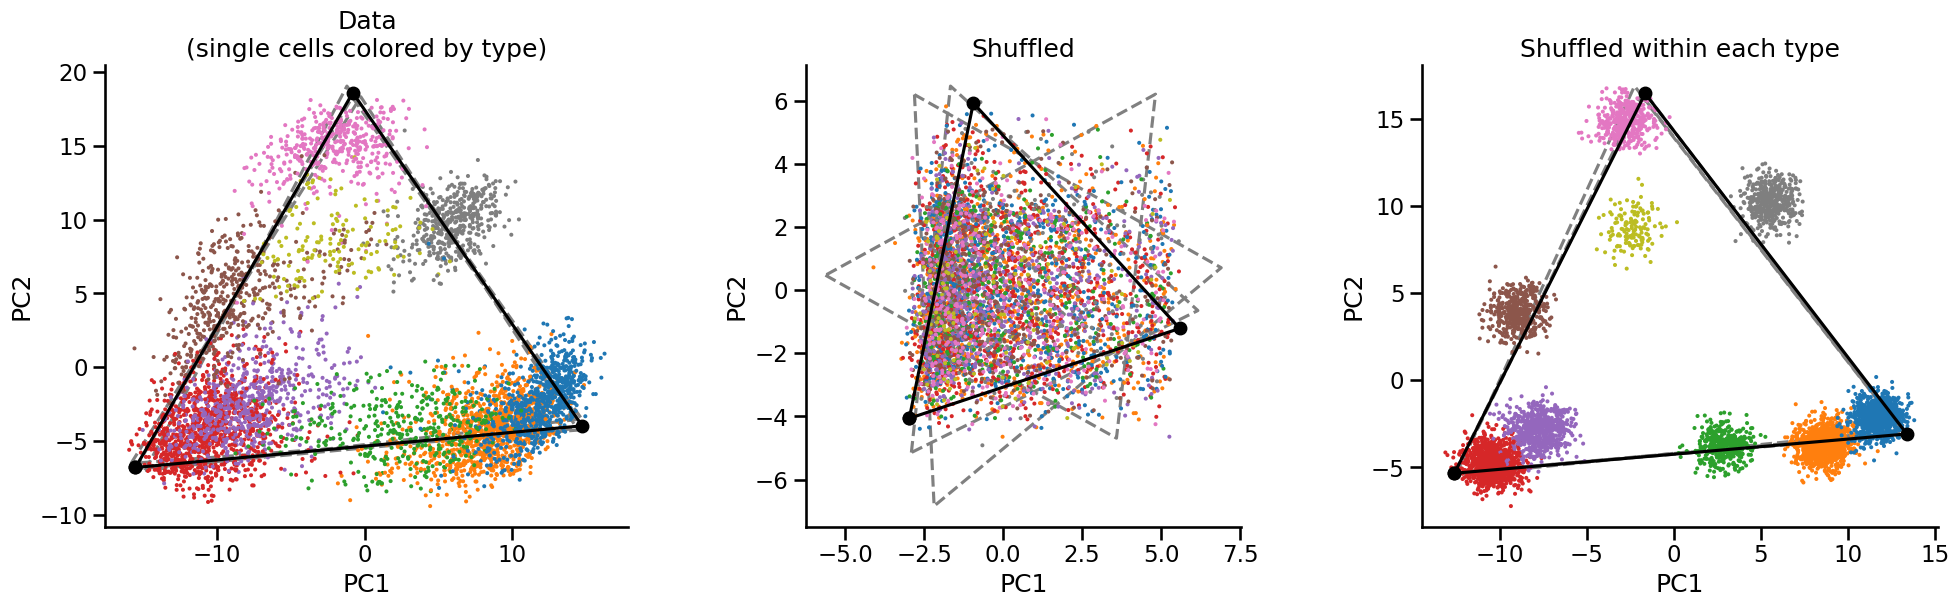

In [16]:
# plot
fig, axs = plt.subplots(1,3,figsize=(8*3,6))
ax = axs[0]
ax.scatter(xp[:,0], xp[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    
ax = axs[1]
ax.set_title('Shuffled')
ax.scatter(xp_gshuff[:,0], xp_gshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_gshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_gshuff_boots[i], fmt='--', color='gray', zorder=0)

ax = axs[2]
ax.set_title('Shuffled within each type')
ax.scatter(xp_tshuff[:,0], xp_tshuff[:,1], c=types_colorvec, s=2)
plot_archetype(ax, aa_tshuff, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_tshuff_boots[i], fmt='--', color='gray', zorder=0)

for i in range(3):
    ax = axs[i]
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal')
    sns.despine(ax=ax)
    ax.grid(False)
    
plt.show()

In [17]:
subclass_colorvec = np.char.add('C', adata_hvg.obs.Subclass.cat.codes.astype(str))

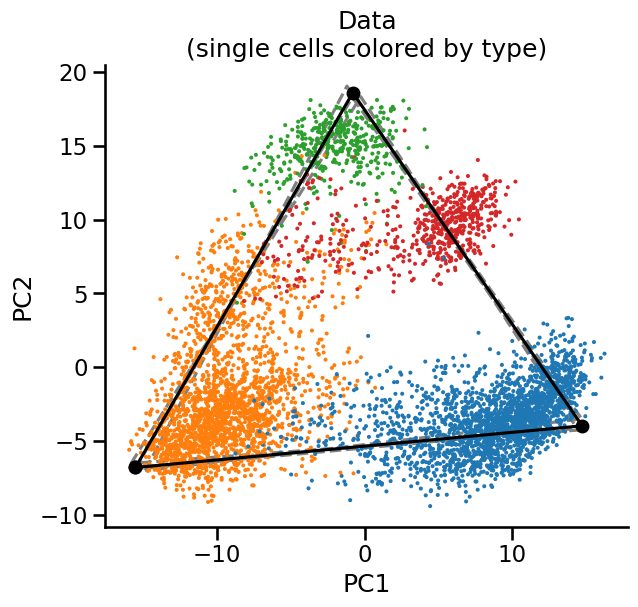

In [18]:
# plot
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
ax.scatter(xp[:,0], xp[:,1], c=subclass_colorvec, s=2)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')
    

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect('equal')
sns.despine(ax=ax)
ax.grid(False)
    
plt.show()

## quantify the level of pointedness 
- t-ratio 

In [19]:
noc  = 3
ndim = noc-1

In [20]:
t_ratio, t_ratio_shuffs, pval = sca.t_ratio_test(ndim, noc, nrepeats=100)
print(f'p-value: {pval}')

use data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
use shuffled data
u

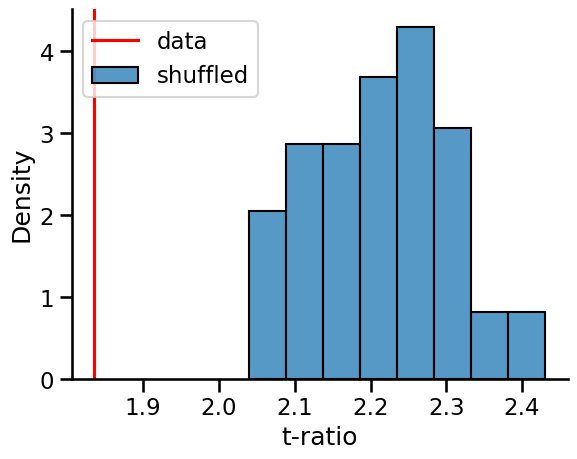

In [21]:
fig, ax = plt.subplots()
ax.axvline(t_ratio, color='r', label='data')
sns.histplot(t_ratio_shuffs, ax=ax, stat='density', label='shuffled')
ax.set_xlabel('t-ratio')
ax.legend()
sns.despine(ax=ax)
plt.show()

# define a transcriptomic order

In [22]:
adata_dpt = adata_hvg
adata_dpt.obsm['pca_later'] = PCA(n_components=10).fit_transform(sca.xn)
adata_dpt

AnnData object with n_obs × n_vars = 5399 × 4720
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'cond'
    var: 'feature_types'
    obsm: 'pca_later'
    layers: 'lognorm', 'norm', 'zlognorm'

In [23]:
pc1 = adata_dpt.obsm['pca_later'][:,0]
pc2 = adata_dpt.obsm['pca_later'][:,1]
gexp = np.array(adata_dpt[:,'Cdh13'].layers['norm']).reshape(-1,)

sc.pp.neighbors(adata_dpt, n_neighbors=30, use_rep='pca_later')
# adata_dpt.uns["iroot"] = np.argmax(gexp) 
adata_dpt.uns["iroot"] = np.argmax(pc1)
sc.tl.diffmap(adata_dpt)
sc.tl.dpt(adata_dpt)

In [24]:
num_bins = 50
xm = (1/2 + np.arange(0,num_bins,1))*1/num_bins
adata_dpt.obs['dpt'] = np.clip(adata_dpt.obs['dpt_pseudotime'].values, a_min=0, a_max=1)

adata_dpt.obs['dpt_bin']  = pd.cut( adata_dpt.obs['dpt'], num_bins, labels=False)
adata_dpt.obs['dpt_qbin'] = pd.qcut(adata_dpt.obs['dpt'], num_bins, labels=False)

cdf = adata_dpt.obs.groupby('dpt_bin').size()
cdf_by_subclass = adata_dpt.obs.groupby(['dpt_bin', 'Subclass']).size().unstack()
cdf_by_type = adata_dpt.obs.groupby(['dpt_bin', 'Type']).size().unstack()

qcdf = adata_dpt.obs.groupby('dpt_qbin').size()
qcdf_by_subclass = adata_dpt.obs.groupby(['dpt_qbin', 'Subclass']).size().unstack()
qcdf_by_type = adata_dpt.obs.groupby(['dpt_qbin', 'Type']).size().unstack()

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

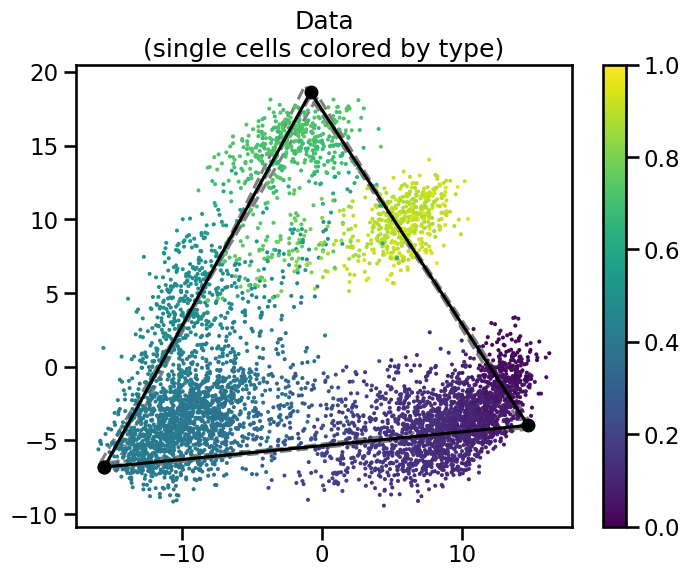

In [25]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=adata_dpt.obs['dpt'].values, s=2)
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

Text(0.5, 1.0, 'Data\n(single cells colored by type)')

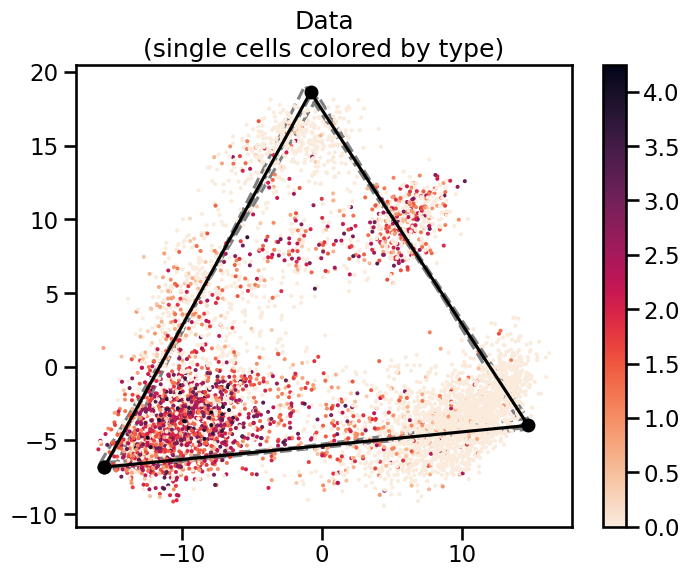

In [26]:
gexp = np.array(adata_dpt[:,'Chrm2'].layers['lognorm']).reshape(-1,)

fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(xp[:,0], xp[:,1], c=gexp, s=2, cmap='rocket_r')
fig.colorbar(g)
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)
for i in range(nrepeats):
    plot_archetype(ax, aa_boots[i], fmt='--', color='gray', zorder=0)
ax.set_title('Data\n(single cells colored by type)')

# 3D plot

In [27]:
pcs = PCA(n_components=5).fit_transform(adata_hvg.layers['lognorm'][...])

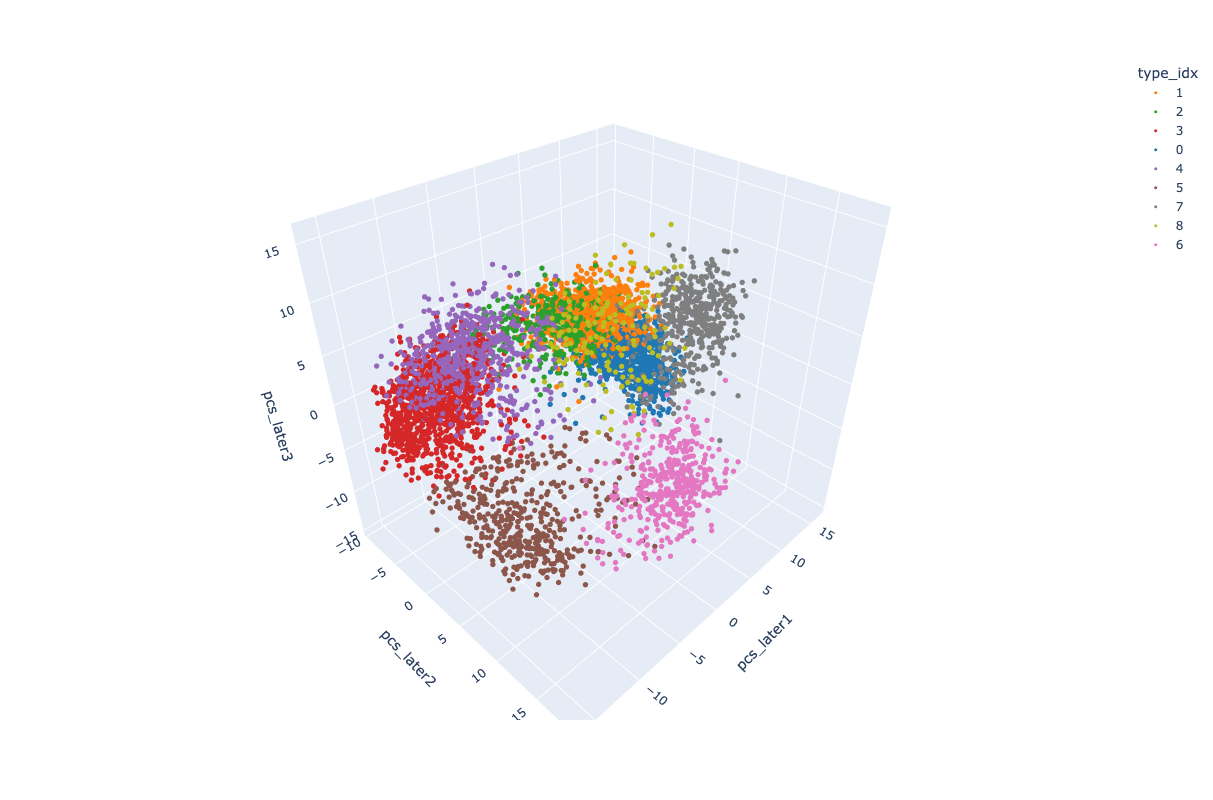

In [28]:
import plotly.express as px

mpl_colors = {
    '0': '#1f77b4', '1': '#ff7f0e', '2': '#2ca02c', '3': '#d62728', '4': '#9467bd',
    '5': '#8c564b', '6': '#e377c2', '7': '#7f7f7f', '8': '#bcbd22', '9': '#17becf'
}

df = pd.DataFrame()
df['pcs_later1'] = pcs[:,0]
df['pcs_later2'] = pcs[:,1]
df['pcs_later3'] = pcs[:,2]
df['type_idx'] = sca.types_idx.astype(str)

fig = px.scatter_3d(df, x='pcs_later1', y='pcs_later2', z='pcs_later3',
                      color='type_idx', 
                      color_discrete_map=mpl_colors,
                   )
fig.update_traces(marker_size=3) 
fig.update_layout(width=1000, height=800)

fig.update_scenes(xaxis_autorange="reversed") 
fig.update_layout(scene_dragmode='orbit')
fig.show()


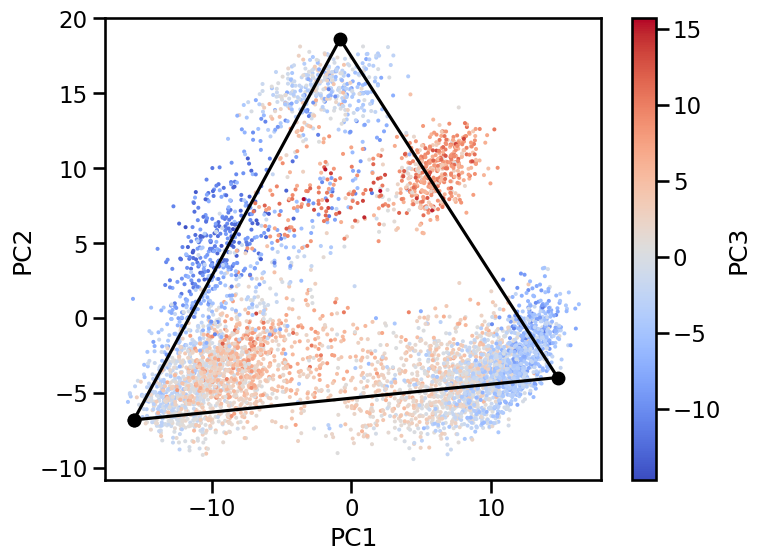

In [29]:
fig, ax = plt.subplots(1,1,figsize=(8*1,6))
g = ax.scatter(df['pcs_later1'], 
               df['pcs_later2'],
               c=df['pcs_later3'], s=2, cmap='coolwarm')
fig.colorbar(g, label='PC3')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plot_archetype(ax, aa, fmt='-o', color='k', zorder=2)

# gene expression as a function of the order
- for all genes 

In [30]:
# get all info
mat = np.log2(1+adata[adata_dpt.obs.index].layers['norm'])
df = pd.DataFrame(mat, columns=adata.var.index, index=adata_dpt.obs.index)
df['dpt'] = adata_dpt.obs['dpt']
df['dpt_bin'] = adata_dpt.obs['dpt_bin']
df['dpt_qbin'] = adata_dpt.obs['dpt_qbin']
yms = df.groupby('dpt_bin').mean()
qyms = df.groupby('dpt_qbin').mean()

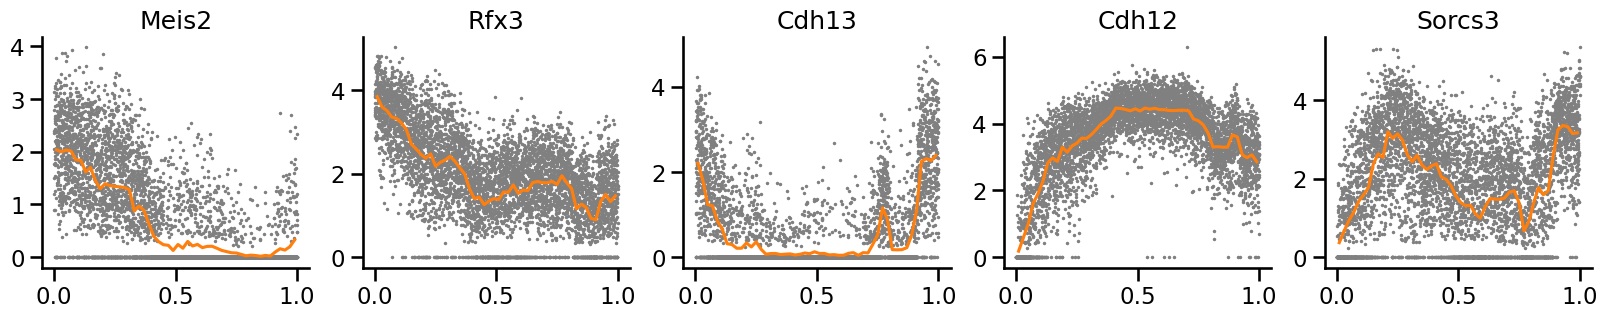

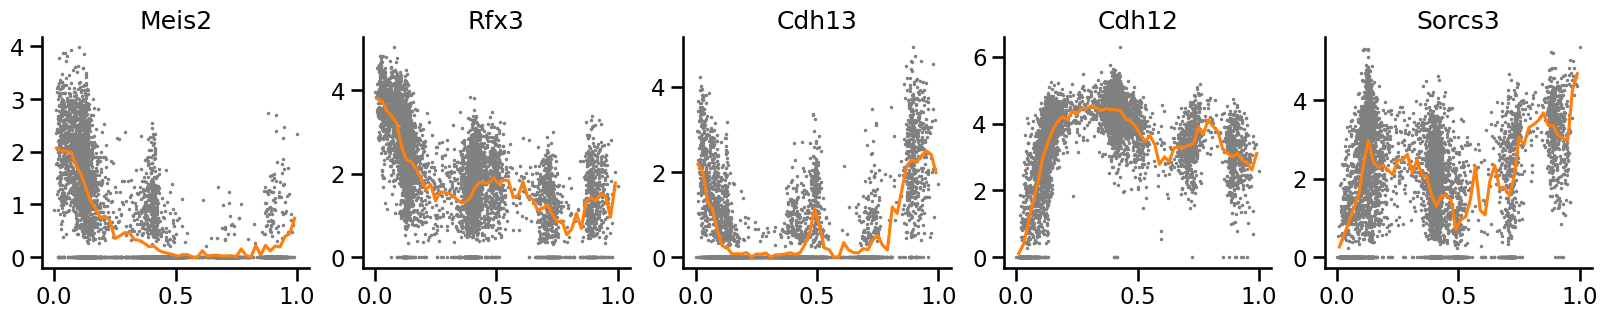

In [31]:
x  = adata_dpt.obs['dpt']
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Meis2', 'Rfx3', 'Cdh13', 'Cdh12', 'Sorcs3',]
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(qx, y, s=1, color='gray')
    
    ax.plot(xm, qyms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(x, y, s=1, color='gray')
    
    ax.plot(xm, yms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

# cell density along dpt as a control

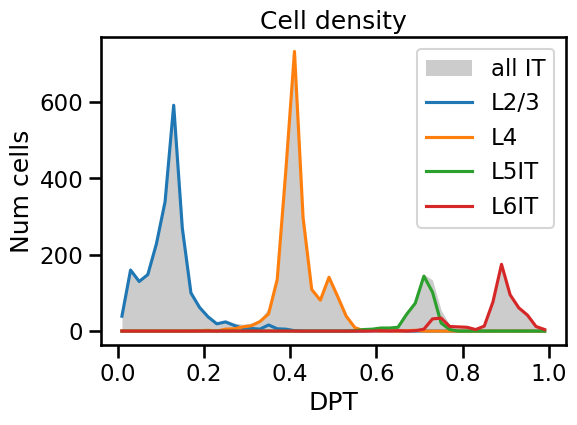

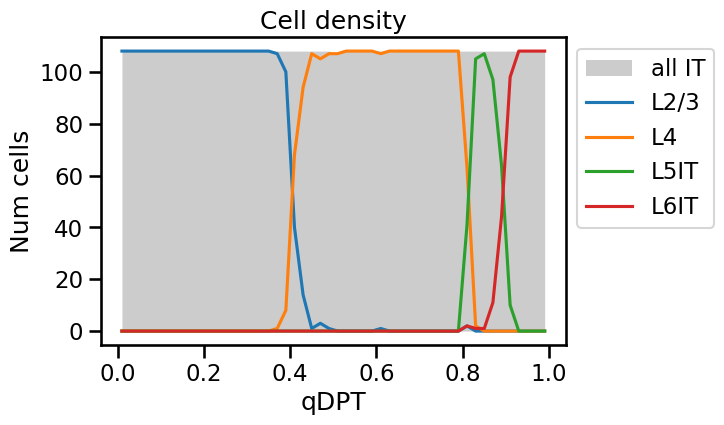

In [32]:
fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, cdf, color='k', label='all IT', alpha=0.2, linewidth=0)
subclasses = ['L2/3', 'L4', 'L5IT', 'L6IT']
for subclass in subclasses:
    ax.plot(xm, cdf_by_subclass[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('DPT')
ax.set_ylabel('Num cells')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, qcdf, color='k', label='all IT', alpha=0.2, linewidth=0)
subclasses = ['L2/3', 'L4', 'L5IT', 'L6IT']
for subclass in subclasses:
    ax.plot(xm, qcdf_by_subclass[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('qDPT')
ax.set_ylabel('Num cells')
plt.show()

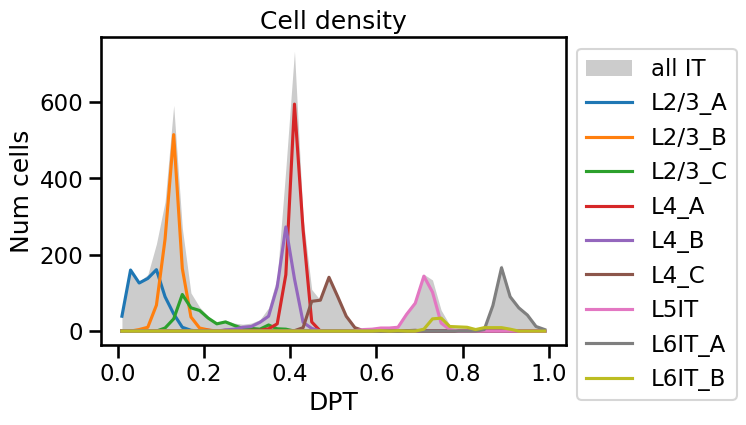

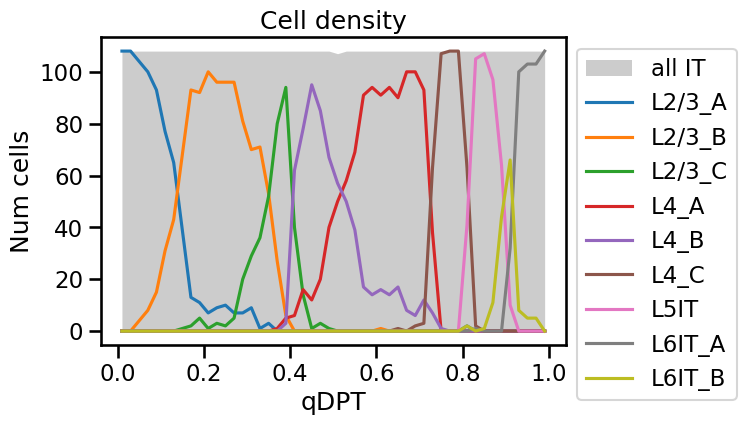

In [33]:
fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, cdf, color='k', label='all IT', alpha=0.2, linewidth=0)
for subclass in cdf_by_type.columns:
    ax.plot(xm, cdf_by_type[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('DPT')
ax.set_ylabel('Num cells')
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.fill_between(xm, 0, qcdf, color='k', label='all IT', alpha=0.2, linewidth=0)
for subclass in qcdf_by_type.columns:
    ax.plot(xm, qcdf_by_type[subclass], label=subclass)
ax.legend(bbox_to_anchor=(1,1))
ax.set_title('Cell density')
ax.set_xlabel('qDPT')
ax.set_ylabel('Num cells')
plt.show()

# Clustering

In [34]:
qyms_hvg = qyms[adata_dpt.var.index]

In [35]:
qzmat_hvg = (qyms_hvg-qyms_hvg.mean())/(1e-6+qyms_hvg.std())

In [36]:
from sklearn.cluster import KMeans

k = 20
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
kmeans.fit(qzmat_hvg.T)

labels = kmeans.labels_          # Cluster assignments for each point
centroids = kmeans.cluster_centers_  # Coordinates of cluster centers

kmeans_order = np.argsort(labels)
ordered_labels = labels[kmeans_order]
unq_labels, abn_counts = np.unique(ordered_labels, return_counts=True)
cum_counts = np.cumsum(abn_counts)

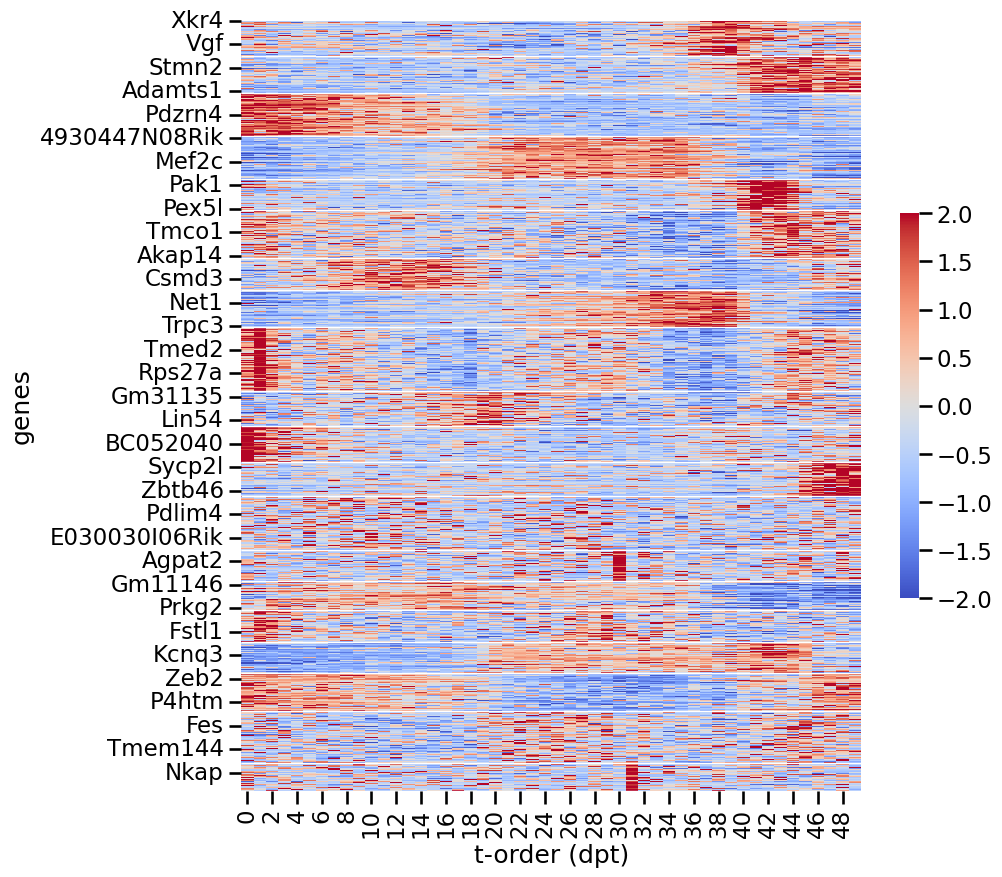

In [37]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(qzmat_hvg.T.iloc[kmeans_order], 
            cbar_kws=dict(shrink=0.5),
            cmap='coolwarm', vmax=2, vmin=-2, 
            ax=ax)
ax.hlines(cum_counts, xmin=0, xmax=100, color='white', linewidth=1)
ax.set_ylabel('genes')
ax.set_xlabel('t-order (dpt)')
plt.show()

In [38]:
from scroutines import basicu

queries = ['Cdh13', 'C1ql3']
labels[basicu.get_index_from_array(adata_dpt.var.index.values, queries)]

array([11, 17], dtype=int32)

In [39]:
gpt = 1/num_bins*np.linspace(0,1,num_bins).dot(np.clip(qzmat_hvg, 0, None)/(1e-7+qzmat_hvg.max()))
# gpt = 1/num_bins*np.linspace(0,1,num_bins).dot((qzmat_hvg-qzmat_hvg.min())/(1e-7+qzmat_hvg.max()))

allgenes_ordered = []
allgenes_avg_gpt = []
for i in range(k):
    genes_sel = adata_dpt.var.index.values[labels==i]
    gpt_sel = gpt[labels==i]
    sel_order = np.argsort(gpt_sel)
    avg_gpt = np.mean(gpt_sel)
    
    genes_ordered = genes_sel[sel_order]
    allgenes_ordered.append(genes_ordered)
    allgenes_avg_gpt.append(avg_gpt)

# reassign cluster memberships
allgenes_ordered = np.array(allgenes_ordered, dtype=object)[
    np.argsort(allgenes_avg_gpt)]# np.hstack(allgenes_ordered_new)

allgenes_ordered = np.hstack(allgenes_ordered)
allgenes_ordered

array(['Cth', 'Ndst4', 'Gm48530', ..., 'B3galt1', 'Ncam2', 'Zfp385b'],
      dtype=object)

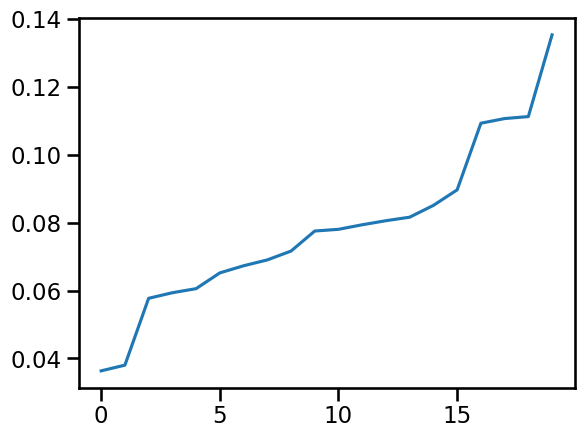

In [40]:
plt.plot(np.array(allgenes_avg_gpt)[np.argsort(allgenes_avg_gpt)])

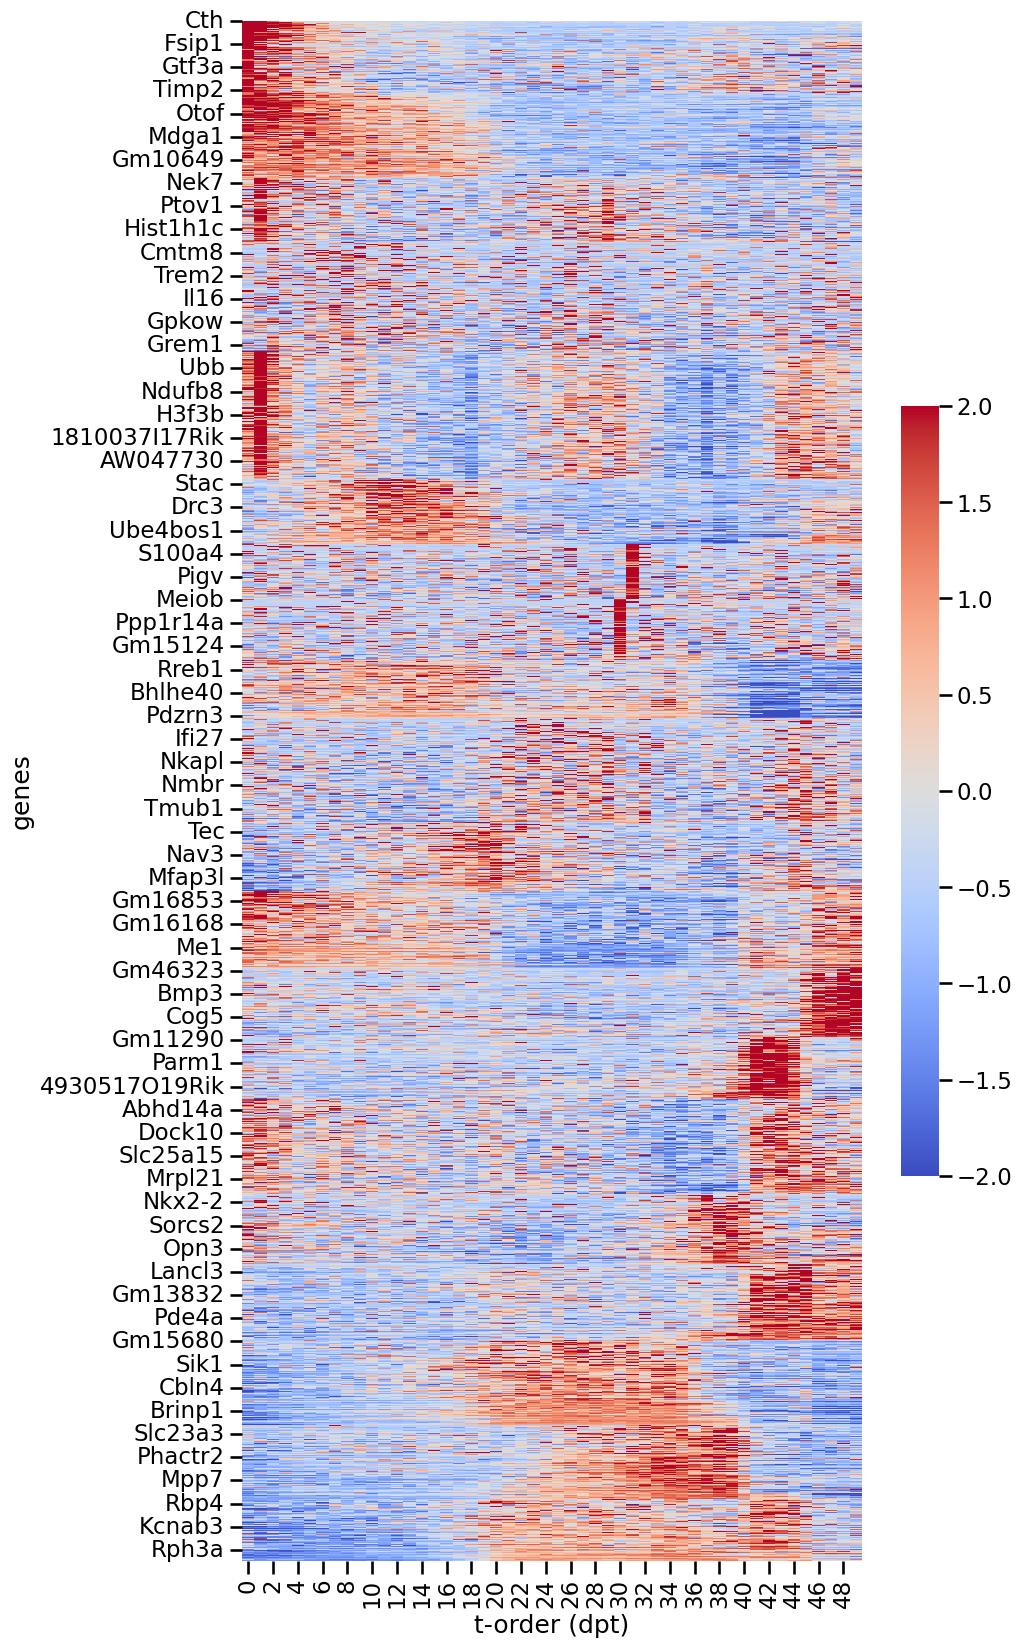

In [41]:
fig, ax = plt.subplots(figsize=(10,20))
sns.heatmap(qzmat_hvg.T.loc[allgenes_ordered], # .iloc[gene_order], 
            cbar_kws=dict(shrink=0.5),
            cmap='coolwarm', vmax=2, vmin=-2, 
            ax=ax)
# ax.hlines(cum_counts, xmin=0, xmax=100, color='white', linewidth=1)
ax.set_ylabel('genes')
ax.set_xlabel('t-order (dpt)')
plt.show()

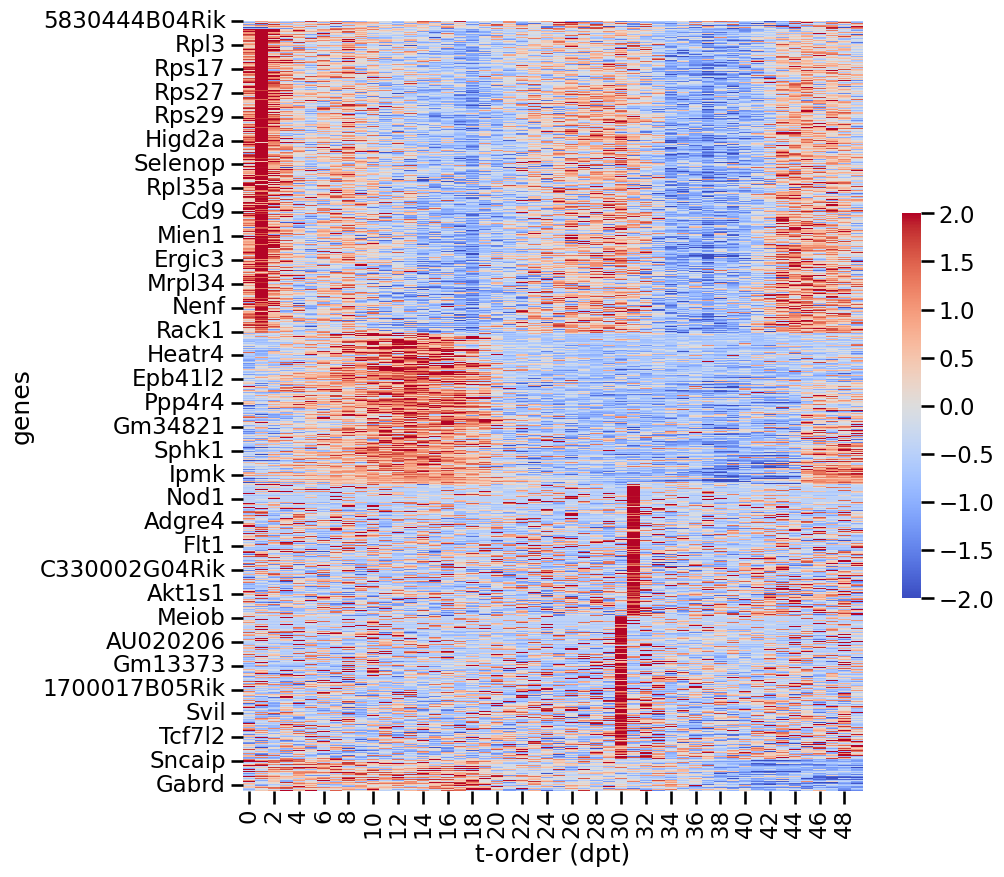

In [42]:
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(qzmat_hvg.T.loc[allgenes_ordered][1000:2000], 
            cbar_kws=dict(shrink=0.5),
            cmap='coolwarm', vmax=2, vmin=-2, 
            ax=ax)
# ax.hlines(cum_counts, xmin=0, xmax=100, color='white', linewidth=1)
ax.set_ylabel('genes')
ax.set_xlabel('t-order (dpt)')
plt.show()

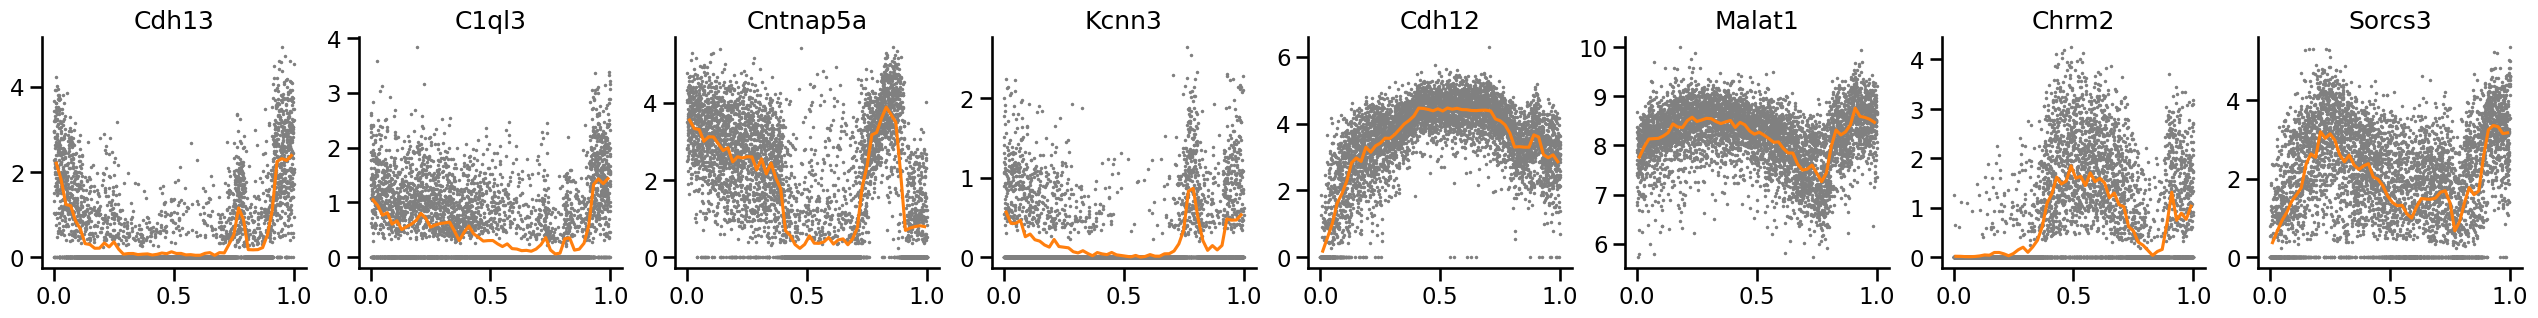

In [44]:
qx = adata_dpt.obs['dpt'].rank(pct=True)

gns = ['Cdh13', 'C1ql3', 'Cntnap5a', 'Kcnn3', 'Cdh12', 'Malat1', 'Chrm2', 'Sorcs3']
n = len(gns)

fig, axs = plt.subplots(1,n,figsize=(n*4,1*3))
for i, gn in enumerate(gns):
    ax = axs[i]
    
    y = np.log2(1+np.array(adata_dpt[:,gn].layers['norm'])).reshape(-1,)
    ax.scatter(qx, y, s=1, color='gray')
    
    ax.plot(xm, qyms[gn], color='C1')
    
    sns.despine(ax=ax)
    ax.set_title(gn)
plt.show()

# explore more gene programs